# Project 4: Sequence Classification with RNN

This notebook loads the attack and benign CSV files, builds fixed-length time sequences per device, trains a recurrent model, and evaluates it with the required classification metrics and ROC curve.


## 1. Install PyTorch

This cell installs the PyTorch packages needed for training neural networks in the notebook.


In [3]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.6/530.6 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 57.1 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 KB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 42.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 28.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 70.7 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.1/188.1 MB 10.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 11.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1

## 2. Import Libraries

This cell imports pandas, NumPy, plotting tools, scikit-learn utilities, and PyTorch modules used throughout the notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 3. Load the Dataset Files

This cell reads the separate attack and benign CSV files into dataframes.


In [2]:
attack_df = pd.read_csv("attack_samples_10sec.csv")
benign_df = pd.read_csv("benign_samples_10sec.csv")

## 4. Add Class Labels

This cell creates the binary target column, using `1` for attack samples and `0` for benign samples.


In [3]:
attack_df["label"] = 1
benign_df["label"] = 0

## 5. Combine the Two Datasets

This cell merges the labeled attack and benign rows into one dataframe and prints the class distribution.


In [4]:
df = pd.concat([attack_df, benign_df], ignore_index=True)
print(df.shape)
print(df["label"].value_counts())

(30030, 95)
1    16350
0    13680
Name: label, dtype: int64


## 6. Inspect the Data

This cell shows the first few rows and the available columns so the feature columns can be chosen correctly.


In [5]:
print(df.head())
print(df.columns)

  device_name         device_mac                           label_full  label1  \
0       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
1       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
2       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
3       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   
4       edge1  dc:a6:32:dc:27:d4  attack_ddos_syn-flood-port-80_edge1  attack   

  label2             label3                  label4  \
0   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
1   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
2   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
3   ddos  syn-flood-port-80  ddos_syn-flood-port-80   
4   ddos  syn-flood-port-80  ddos_syn-flood-port-80   

                                           timestamp  \
0  2025-01-23T15:31:10.709000Z_2025-01-23T15:31:2...   
1  2025-01-23T15:31:15.709000Z_2025-01-23T15:31:2...   
2  2025-01-23T

## 7. Convert Timestamps and Sort the Rows

This cell converts the timestamp columns to datetime values, removes invalid timestamps, and sorts the data by device and time.


In [6]:
df["timestamp_start"] = pd.to_datetime(df["timestamp_start"], errors="coerce")
df["timestamp_end"] = pd.to_datetime(df["timestamp_end"], errors="coerce")

df = df.dropna(subset=["timestamp_start", "timestamp_end"]).copy()
df = df.sort_values(["device_name", "device_mac", "timestamp_start"]).reset_index(drop=True)

## 8. Clean and Prepare the Selected Features

This cell keeps only the six selected numeric features, converts them to numeric values, and removes rows with missing values in those features.


In [7]:
df["timestamp_start"] = pd.to_datetime(df["timestamp_start"], errors="coerce")
df["timestamp_end"] = pd.to_datetime(df["timestamp_end"], errors="coerce")

df = df.dropna(subset=["timestamp_start", "timestamp_end"]).copy()
df = df.sort_values(["device_name", "device_mac", "timestamp_start"]).reset_index(drop=True)

selected_features = [
    "network_packet-size_avg",
    "network_packet-size_std_deviation",
    "network_payload-length_avg",
    "network_time-delta_avg",
    "network_ttl_avg",
    "network_header-length_avg"
]

# convert to numeric
for c in selected_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# fill missing values instead of deleting all rows
df[selected_features] = df[selected_features].fillna(method="ffill")
df[selected_features] = df[selected_features].fillna(method="bfill")
df[selected_features] = df[selected_features].fillna(df[selected_features].median())

print("After cleaning:", df.shape)
print(df[selected_features].isna().sum())

After cleaning: (30030, 95)
network_packet-size_avg              0
network_packet-size_std_deviation    0
network_payload-length_avg           0
network_time-delta_avg               0
network_ttl_avg                      0
network_header-length_avg            0
dtype: int64


## 9. Define the Sequence Builder

This cell creates the function that groups rows by device, sorts them in time order, and converts them into fixed-length sequences.


In [8]:
SEQ_LEN = 10
STRIDE = 1

def build_sequences(dataframe, feature_columns, label_col="label",
                    group_cols=("device_name", "device_mac"),
                    time_col="timestamp_start",
                    seq_len=10, stride=1):
    X, y = [], []

    # clean group columns
    dataframe = dataframe.copy()
    dataframe["device_name"] = dataframe["device_name"].astype(str).str.strip()
    dataframe["device_mac"] = dataframe["device_mac"].astype(str).str.strip()

    grouped = dataframe.groupby(list(group_cols), sort=False)

    for _, g in grouped:
        g = g.sort_values(time_col).reset_index(drop=True)

        features = g[feature_columns].to_numpy(dtype=np.float32)
        labels = g[label_col].to_numpy(dtype=np.int64)

        if len(g) == 0:
            continue

        if len(g) < seq_len:
            pad_len = seq_len - len(g)
            pad_x = np.zeros((pad_len, features.shape[1]), dtype=np.float32)
            x_seq = np.vstack([features, pad_x])
            y_seq = int(labels[-1])
            X.append(x_seq)
            y.append(y_seq)
        else:
            for start in range(0, len(g) - seq_len + 1, stride):
                end = start + seq_len
                x_seq = features[start:end]
                y_seq = int(labels[end - 1])
                X.append(x_seq)
                y.append(y_seq)

    if len(X) == 0:
        return np.empty((0, seq_len, len(feature_columns)), dtype=np.float32), np.empty((0,), dtype=np.int64)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

## 10. Build the Sequences

This cell applies the sequence-building function and produces the final `X` and `y` arrays used by the model.


In [9]:
X, y = build_sequences(
    df,
    feature_columns=selected_features,
    label_col="label",
    group_cols=("device_name", "device_mac"),
    time_col="timestamp_start",
    seq_len=10,
    stride=1
)

print(X.shape)  # (num_sequences, 10, 6)
print(y.shape)

(29688, 10, 6)
(29688,)


## 11. Split Into Train and Test Sets

This cell performs the required 70/30 train-test split using stratification so both classes stay balanced.


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(20781, 10, 6) (8907, 10, 6)


## 12. Scale the Features

This cell standardizes the features using statistics from the training set only, then reshapes the data back into sequence form.


In [11]:
from sklearn.preprocessing import StandardScaler

# reshape for scaling
num_samples, seq_len, num_features = X_train.shape

scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, num_features)
X_test_reshaped = X_test.reshape(-1, num_features)

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# reshape back
X_train = X_train_scaled.reshape(num_samples, seq_len, num_features)
X_test = X_test_scaled.reshape(X_test.shape[0], seq_len, num_features)

## 13. Create a PyTorch Dataset and DataLoader

This cell wraps the sequence arrays in a custom dataset class and prepares mini-batches for training and testing.


In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(SeqDataset(X_test, y_test), batch_size=64, shuffle=False)

## 14. Define the RNN Model

This cell defines a simple recurrent neural network classifier for binary sequence classification.


In [13]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h = self.rnn(x)
        return self.fc(h[-1]).squeeze()

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1]).squeeze()

## 15. Create the Model Instance

This cell creates the RNN model using the selected number of input features.


In [15]:
input_size = 6  # because you selected 6 features

model = RNNModel(input_size)

## 16. Set the Loss Function and Optimizer

This cell defines the binary cross-entropy loss with logits and the Adam optimizer used during training.


In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 17. Repeat the Training Setup

This cell repeats the loss and optimizer setup, likely as a duplicate or checkpointed step in the notebook.


In [17]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 18. Set the Device

This cell forces training to run on the CPU, which is fine for this assignment if CUDA is not available.


In [18]:
device = torch.device("cpu")

## 19. Train the RNN

This cell runs the full training loop for several epochs, updating the model weights on each batch.


In [20]:
EPOCHS = 100

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        outputs = model(Xb)              # forward pass
        loss = criterion(outputs, yb)    # compute loss

        loss.backward()                  # backprop
        optimizer.step()                 # update weights

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 30.7324
Epoch 2, Loss: 27.6143
Epoch 3, Loss: 26.6137
Epoch 4, Loss: 25.2218
Epoch 5, Loss: 24.2809
Epoch 6, Loss: 23.0688
Epoch 7, Loss: 22.0535
Epoch 8, Loss: 21.1167
Epoch 9, Loss: 21.1134
Epoch 10, Loss: 19.6508
Epoch 11, Loss: 19.2368
Epoch 12, Loss: 19.0552
Epoch 13, Loss: 17.5656
Epoch 14, Loss: 17.6574
Epoch 15, Loss: 17.5856
Epoch 16, Loss: 17.0644
Epoch 17, Loss: 15.8579
Epoch 18, Loss: 15.6059
Epoch 19, Loss: 15.3684
Epoch 20, Loss: 14.7075
Epoch 21, Loss: 14.6912
Epoch 22, Loss: 14.2560
Epoch 23, Loss: 14.6081
Epoch 24, Loss: 13.1016
Epoch 25, Loss: 14.2410
Epoch 26, Loss: 13.1974
Epoch 27, Loss: 12.8336
Epoch 28, Loss: 12.5541
Epoch 29, Loss: 11.3579
Epoch 30, Loss: 12.9768
Epoch 31, Loss: 11.0116
Epoch 32, Loss: 11.2614
Epoch 33, Loss: 10.6262
Epoch 34, Loss: 12.0315
Epoch 35, Loss: 10.3863
Epoch 36, Loss: 10.6162
Epoch 37, Loss: 9.8278
Epoch 38, Loss: 10.6440
Epoch 39, Loss: 9.6201
Epoch 40, Loss: 8.7756
Epoch 41, Loss: 9.8187
Epoch 42, Loss: 9.0809
Epoch 

## 20. Make Predictions on the Test Set

This cell switches the model to evaluation mode and collects predicted probabilities and classes for the test data.


In [21]:
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)

        outputs = model(Xb)
        probs = torch.sigmoid(outputs).cpu().numpy()

        y_prob.extend(probs.tolist())
        y_true.extend(yb.numpy().tolist())
        y_pred.extend((probs >= 0.5).astype(int).tolist())

## 21. Compute Evaluation Metrics

This cell calculates Accuracy, Precision, Recall, F1-score, and Matthews Correlation Coefficient.


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("MCC:", mcc)

Accuracy: 0.9843942966206355
Precision: 0.9888888888888889
Recall: 0.9820945242556736
F1-score: 0.9854799958215815
MCC: 0.9686404358871793


## 22. Plot the ROC Curve

This cell plots the ROC curve and calculates the AUC score for the model predictions.


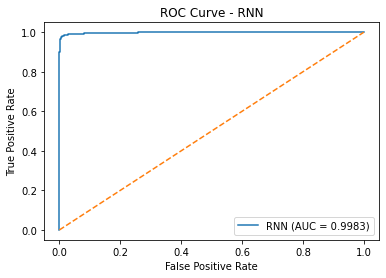

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"RNN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RNN")
plt.legend()
plt.show()